In [1]:
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
from rich import print

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load in dataset
adata = sc.read("/rds/general/user/ztb25/home/PBMC_datasets/integrated_adata.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 880872 × 12711
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'bbknn', 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'harmony', 'hvg', 'neighbors', 'neighbors_unintegrated', 'pca', 'sample_combined_colors', 'scANVI', 'scanorama', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scANVI', 'X_scVI', 'X_scanorama', 'X_umap', 'X_umap_bbknn', 'X_umap_harmony', 'X_umap_scANVI', 'X_umap_scVI', 'X_umap_scanoram

In [4]:
# rename obsm keys for plotting
adata.obsm["Harmony"] = adata.obsm["X_pca_harmony"]
adata.obsm["scVI"] = adata.obsm["X_scVI"]
adata.obsm["scANVI"] = adata.obsm["X_scANVI"]
adata.obsm["Scanorama"] = adata.obsm["X_scanorama"]
adata.obsm["Unintegrated"] = adata.obsm["X_pca"]

In [5]:
bm = Benchmarker(
    adata,
    batch_key="dataset",
    label_key="celltypist_cell_label_fine",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=["Harmony","Unintegrated", "scVI", "scANVI", "Scanorama"],
    n_jobs=16,
)
bm.benchmark()

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


Computing neighbors:   0%|          | 0/5 [00:00<?, ?it/s]

Computing neighbors:  20%|██        | 1/5 [03:14<12:59, 194.92s/it]

Computing neighbors:  40%|████      | 2/5 [06:32<09:49, 196.48s/it]

Computing neighbors:  60%|██████    | 3/5 [09:30<06:15, 187.83s/it]

...

Metrics:  80%|████████  | 8/10 [14:45:26<1:17:24, 2322.20s/it, Batch correction: graph_connectivity]

Metrics:  80%|████████  | 8/10 [14:45:27<1:17:24, 2322.20s/it, Batch correction: pcr_comparison]    

Metrics:  90%|█████████ | 9/10 [14:45:30<26:37, 1597.52s/it, Batch correction: pcr_comparison]  

Embeddings: 100%|██████████| 5/5 [43:52:45<00:00, 30950.49s/it]  

Embeddings: 100%|██████████| 5/5 [43:52:45<00:00, 31593.02s/it]

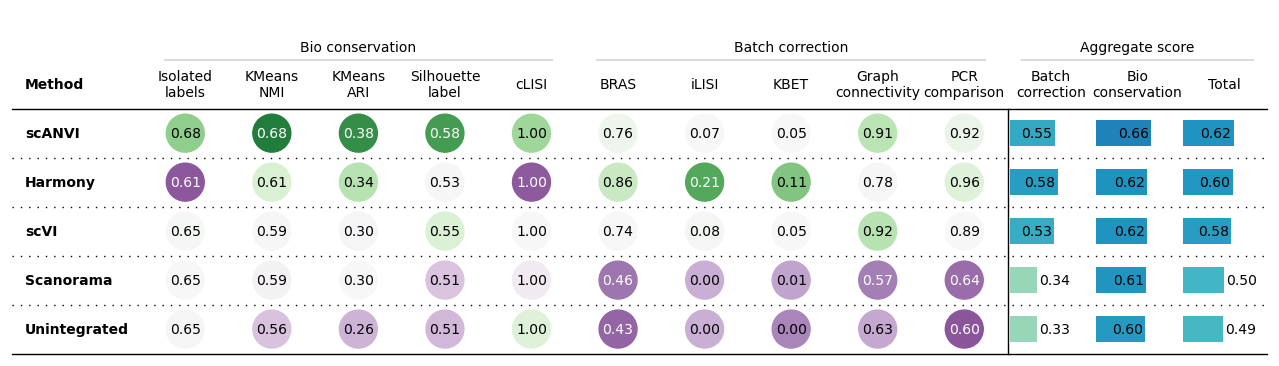

In [6]:
bm.plot_results_table(save_dir="/rds/general/user/ztb25/home/Figures/Unscaled", min_max_scale=False)

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scib_metrics/benchmark/_core.py:307: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Aggregate score' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[_METRIC_TYPE, per_class_score.columns] = _AGGREGATE_SCORE
/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scib_metrics/benchmark/_core.py:307: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Aggregate score' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[_METRIC_TYPE, per_class_score.columns] = _AGGREGATE_SCORE
/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scib_metrics/benchmark/_core.py:307: FutureWarning: Setting an item of

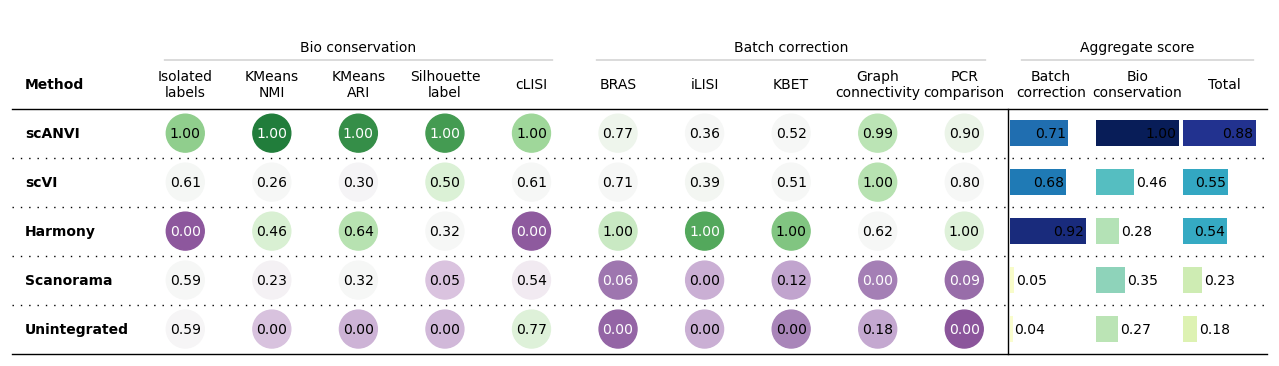

In [7]:
bm.plot_results_table(save_dir="/rds/general/user/ztb25/home/Figures/Scaled", min_max_scale=True)

In [8]:
df = bm.get_results(min_max_scale=False)
print(df)

Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                            
Harmony               0.614395          0.614168          0.336668   
Unintegrated          0.650965          0.560134          0.259163   
scVI                  0.652297          0.591523          0.296011   
scANVI                0.676778          0.678817          0.380729   
Scanorama             0.651494          0.587751          0.298494   
Metric Type   Bio conservation  Bio conservation  Bio conservation   

              Silhouette label             cLISI              BRAS  \
Embedding                                                            
Harmony               0.532021          0.998091           0.85916   
Unintegrated          0.508528          0.999392          0.434567   
scVI                  0.545476          0.999129          0.735415   
scANVI                0.582131          0.999791          0.763605   
Scanorama             0.511996          0.999009          0.458746   
Metric Type   Bio conservation  Bio conservation  Batch correction   

                         iLISI              KBET Graph connectivity  \
Embedding                                                             
Harmony               0.205742          0.105394           0.783513   
Unintegrated               0.0          0.000573           0.629442   
scVI                  0.079826          0.054006           0.915152   
scANVI                0.074538          0.054581           0.910824   
Scanorama                  0.0          0.012629           0.568141   
Metric Type   Batch correction  Batch correction   Batch correction   

                PCR comparison Batch correction Bio conservation  \
Embedding                                                          
Harmony               0.958975         0.582557         0.619068   
Unintegrated          0.604785         0.333874         0.595636   
scVI                  0.889551          0.53479         0.616887   
scANVI                0.923676         0.545445         0.663649   
Scanorama             0.635588         0.335021         0.609749   
Metric Type   Batch correction  Aggregate score  Aggregate score   

                        Total  
Embedding                      
Harmony              0.604464  
Unintegrated         0.490931  
scVI                 0.584048  
scANVI               0.616367  
Scanorama            0.499858  
Metric Type   Aggregate score

In [9]:
df.transpose()

Embedding,Harmony,Unintegrated,scVI,scANVI,Scanorama,Metric Type
Isolated labels,0.614395,0.650965,0.652297,0.676778,0.651494,Bio conservation
KMeans NMI,0.614168,0.560134,0.591523,0.678817,0.587751,Bio conservation
KMeans ARI,0.336668,0.259163,0.296011,0.380729,0.298494,Bio conservation
Silhouette label,0.532021,0.508528,0.545476,0.582131,0.511996,Bio conservation
cLISI,0.998091,0.999392,0.999129,0.999791,0.999009,Bio conservation
BRAS,0.85916,0.434567,0.735415,0.763605,0.458746,Batch correction
iLISI,0.205742,0.0,0.079826,0.074538,0.0,Batch correction
KBET,0.105394,0.000573,0.054006,0.054581,0.012629,Batch correction
Graph connectivity,0.783513,0.629442,0.915152,0.910824,0.568141,Batch correction
PCR comparison,0.958975,0.604785,0.889551,0.923676,0.635588,Batch correction


In [10]:
df2 = bm.get_results(min_max_scale=True)
print(df2)

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scib_metrics/benchmark/_core.py:307: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Aggregate score' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[_METRIC_TYPE, per_class_score.columns] = _AGGREGATE_SCORE
/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scib_metrics/benchmark/_core.py:307: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Aggregate score' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[_METRIC_TYPE, per_class_score.columns] = _AGGREGATE_SCORE
/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scib_metrics/benchmark/_core.py:307: FutureWarning: Setting an item of

Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                            
Harmony                    0.0          0.455277          0.637554   
Unintegrated           0.58621               0.0               0.0   
scVI                  0.607556          0.264476           0.30311   
scANVI                     1.0               1.0               1.0   
Scanorama             0.594696          0.232694          0.323534   
Metric Type   Bio conservation  Bio conservation  Bio conservation   

              Silhouette label             cLISI              BRAS  \
Embedding                                                            
Harmony               0.319183               0.0               1.0   
Unintegrated               0.0          0.765337               0.0   
scVI                  0.501999          0.610636          0.708556   
scANVI                     1.0               1.0          0.774951   
Scanorama             0.047124          0.540384          0.056947   
Metric Type   Bio conservation  Bio conservation  Batch correction   

                         iLISI              KBET Graph connectivity  \
Embedding                                                             
Harmony                    1.0               1.0            0.62065   
Unintegrated               0.0               0.0           0.176655   
scVI                  0.387991          0.509754                1.0   
scANVI                0.362285          0.515237           0.987528   
Scanorama             0.000001          0.115011                0.0   
Metric Type   Batch correction  Batch correction   Batch correction   

                PCR comparison Batch correction Bio conservation  \
Embedding                                                          
Harmony                    1.0          0.92413         0.282403   
Unintegrated               0.0         0.035331         0.270309   
scVI                  0.803991         0.682059         0.457555   
scANVI                0.900337         0.708068              1.0   
Scanorama             0.086966         0.051785         0.347686   
Metric Type   Batch correction  Aggregate score  Aggregate score   

                        Total  
Embedding                      
Harmony              0.539094  
Unintegrated         0.176318  
scVI                 0.547357  
scANVI               0.883227  
Scanorama            0.229326  
Metric Type   Aggregate score

In [11]:
df2.transpose()

Embedding,Harmony,Unintegrated,scVI,scANVI,Scanorama,Metric Type
Isolated labels,0.0,0.58621,0.607556,1.0,0.594696,Bio conservation
KMeans NMI,0.455277,0.0,0.264476,1.0,0.232694,Bio conservation
KMeans ARI,0.637554,0.0,0.30311,1.0,0.323534,Bio conservation
Silhouette label,0.319183,0.0,0.501999,1.0,0.047124,Bio conservation
cLISI,0.0,0.765337,0.610636,1.0,0.540384,Bio conservation
BRAS,1.0,0.0,0.708556,0.774951,0.056947,Batch correction
iLISI,1.0,0.0,0.387991,0.362285,0.000001,Batch correction
KBET,1.0,0.0,0.509754,0.515237,0.115011,Batch correction
Graph connectivity,0.62065,0.176655,1.0,0.987528,0.0,Batch correction
PCR comparison,1.0,0.0,0.803991,0.900337,0.086966,Batch correction
